In [ ]:
## load basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Seaborn is a python libraray used for creating beautiful and statstical data visualization. It is a built on top of Matplotlib and simplifies plotting


In [ ]:
data=sns.load_dataset("iris")


In [ ]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
data1=data[data["species"]!="setosa"]
data1

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
data1["species"].unique()

array(['versicolor', 'virginica'], dtype=object)

In [ ]:
np.array(['versicolor','virginica'],dtype=object)

array(['versicolor', 'virginica'], dtype=object)

In [ ]:
data1["species"] = data1["species"].map({"versicolor": 0, "virginica": 1})
data1

/tmp/ipykernel_5176/871710278.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1["species"] = data1["species"].map({"versicolor": 0, "virginica": 1})


,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,0
51,6.4,3.2,4.5,1.5,0
52,6.9,3.1,4.9,1.5,0
53,5.5,2.3,4.0,1.3,0
54,6.5,2.8,4.6,1.5,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,1
146,6.3,2.5,5.0,1.9,1
147,6.5,3.0,5.2,2.0,1
148,6.2,3.4,5.4,2.3,1


In [ ]:
data1["species"].unique()

array([0, 1])

In [ ]:
np.array([0,1])

array([0, 1])

Divide in input and output


In [ ]:
x=data1.iloc[:,:-1]
y=data1.iloc[:,-1]

In [ ]:
x.head(2)

,sepal_length,sepal_width,petal_length,petal_width
50,7.0,3.2,4.7,1.4
51,6.4,3.2,4.5,1.5


In [ ]:
y.head()

,species
50,0
51,0
52,0
53,0
54,0


In [ ]:
#Data Splition

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
x_train.head()

,sepal_length,sepal_width,petal_length,petal_width
65,6.7,3.1,4.4,1.4
90,5.5,2.6,4.4,1.2
146,6.3,2.5,5.0,1.9
59,5.2,2.7,3.9,1.4
122,7.7,2.8,6.7,2.0


In [ ]:
y_train.head()

,species
65,0
90,0
146,1
59,0
122,1


In [ ]:
### Model Building Part

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic_model=LogisticRegression()
logistic_model.fit(x_train,y_train)    #1/1+e^-z==>  z=m1*1+m2*2+m3*3+m4*4+C

LogisticRegression()

In [ ]:
y_pred=logistic_model.predict(x_test)

In [ ]:
y_test,y_pred

(133    1
 103    1
 120    1
 95     0
 94     0
 89     0
 72     0
 130    1
 60     0
 50     0
 68     0
 80     0
 123    1
 83     0
 140    1
 54     0
 126    1
 127    1
 62     0
 81     0
 105    1
 138    1
 76     0
 92     0
 119    1
 Name: species, dtype: int64,
 array([1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0,
        0, 0, 1]))

In [ ]:
x_pred=logistic_model.predict(x_train)

Model Evaluation


In [ ]:
from sklearn.metrics import accuracy_score,classification_report

In [ ]:
print("Training Accuracy:",accuracy_score(y_train,x_pred))
print("Testing Accuracy:",accuracy_score(y_test,y_pred))

Training Accuracy: 0.9733333333333334
Testing Accuracy: 0.92


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.91      0.91      0.91        11

    accuracy                           0.92        25
   macro avg       0.92      0.92      0.92        25
weighted avg       0.92      0.92      0.92        25



KNN ( k Nearest Neighbour )

In [ ]:
###KNN

In [ ]:
#KNN is a supervised machine learning algorithm used for both classification and regression
#KNN is a method used to store data which we provided
#If having large K  more the prediction  chance will be more
#KNN is also called lazy algorithm as it works slow


Classifier


In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
X=np.array(([1],
            [2],
            [3],
            [4],
            [5],
            [6],
            [7],
            [8]))
Y=np.array([
    "Fail",
    "Fail",
    "Fail",
    "pass",
    "Pass",
    "Pass",
    "Pass",
    "Pass"
])
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X,Y)
prediction = model.predict([[3.5]])
print(prediction)

['Fail']


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

X = [[1,2],[2,3],[3,3],[6,5],[7,7],[8,6]]
Y = [0,0,0,1,1,1]

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X,Y)
prediction = knn.predict([[5,5]])
print(prediction)


[1]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

X=[[1],[2],[3],[4],[5],[6]]
Y=['Fail','Fail','Fail','Pass','Pass','Pass']

model=KNeighborsClassifier(n_neighbors=3)
model.fit(X,Y)
result=model.predict([[3.5]])
print(result)
#knn prefers to more odd value as compared to the more even value

['Fail']


Regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

x=[[1],[2],[3],[4],[5]]
y=[10,20,30,40,50]

model=KNeighborsRegressor(n_neighbors=3)
model.fit(x,y)
prediction=model.predict([[3.5]])
print(prediction)

[30.]


Decision Tree


In [ ]:
#load basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=sns.load_dataset("iris")
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
from sklearn.datasets import load_iris

In [ ]:
data1=load_iris()
data1

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [ ]:
x=data1["data"]
y=data1["target"]

In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

Data Splition part


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)
x_train,y_train

(array([[5.5, 2.4, 3.7, 1. ],
        [6.3, 2.8, 5.1, 1.5],
        [6.4, 3.1, 5.5, 1.8],
        [6.6, 3. , 4.4, 1.4],
        [7.2, 3.6, 6.1, 2.5],
        [5.7, 2.9, 4.2, 1.3],
        [7.6, 3. , 6.6, 2.1],
        [5.6, 3. , 4.5, 1.5],
        [5.1, 3.5, 1.4, 0.2],
        [7.7, 2.8, 6.7, 2. ],
        [5.8, 2.7, 4.1, 1. ],
        [5.2, 3.4, 1.4, 0.2],
        [5. , 3.5, 1.3, 0.3],
        [5.1, 3.8, 1.9, 0.4],
        [5. , 2. , 3.5, 1. ],
        [6.3, 2.7, 4.9, 1.8],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [5.6, 2.7, 4.2, 1.3],
        [5.1, 3.4, 1.5, 0.2],
        [5.7, 3. , 4.2, 1.2],
        [7.7, 3.8, 6.7, 2.2],
        [4.6, 3.2, 1.4, 0.2],
        [6.2, 2.9, 4.3, 1.3],
        [5.7, 2.5, 5. , 2. ],
        [5.5, 4.2, 1.4, 0.2],
        [6. , 3. , 4.8, 1.8],
        [5.8, 2.7, 5.1, 1.9],
        [6. , 2.2, 4. , 1. ],
        [5.4, 3. , 4.5, 1.5],
        [6.2, 3.4, 5.4, 2.3],
        [5.5, 2.3, 4. , 1.3],
        [5

Model Building Part

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model1=DecisionTreeClassifier(max_depth=2)
model1.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=2)

[Text(0.4, 0.8333333333333334, 'x[3] <= 0.8\ngini = 0.664\nsamples = 105\nvalue = [31, 37, 37]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 31\nvalue = [31, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[3] <= 1.75\ngini = 0.5\nsamples = 74\nvalue = [0, 37, 37]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.214\nsamples = 41\nvalue = [0, 36, 5]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.059\nsamples = 33\nvalue = [0, 1, 32]')]

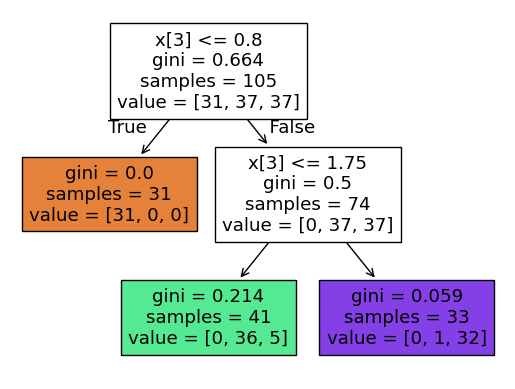

In [ ]:
from sklearn import tree
tree.plot_tree(model1,filled=True)

In [ ]:
y_pred=model1.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [ ]:
print("Texting acc:",accuracy_score(y_test,y_pred))

Texting acc: 1.0


In [ ]:
print(confusion_matrix(y_test,y_pred))

[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


PostPruning


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model1=DecisionTreeClassifier(max_depth=2)
model1.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=2)

[Text(0.4, 0.8333333333333334, 'x[3] <= 0.8\ngini = 0.664\nsamples = 105\nvalue = [31, 37, 37]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 31\nvalue = [31, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[3] <= 1.75\ngini = 0.5\nsamples = 74\nvalue = [0, 37, 37]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.214\nsamples = 41\nvalue = [0, 36, 5]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.059\nsamples = 33\nvalue = [0, 1, 32]')]

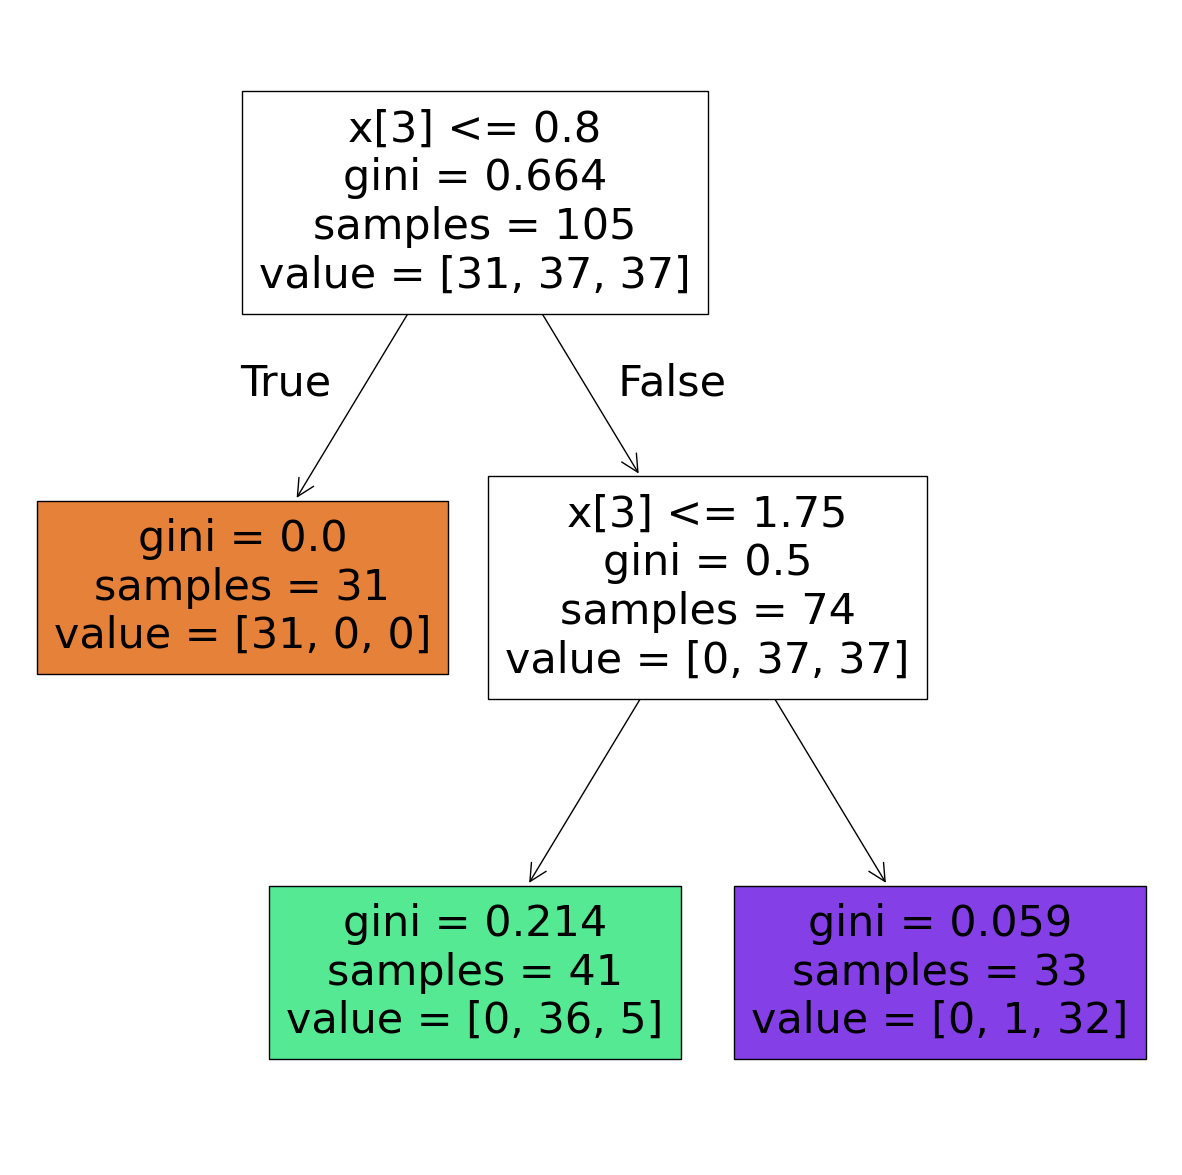

In [ ]:
from sklearn import tree
plt.figure(figsize=(15,15))
tree.plot_tree(model1,filled=True)